In [4]:
# Packages

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


from scipy.stats import norm #Normal PDF and CDF
from numpy.random import normal # normal random variable

## Black-Scholes Equation

The Black-Scholes theorem assume that the stock price follows a geometric Brownian motion, given by,
\begin{align}
dS = \mu S dt + \sigma S dz
\end{align}
where $\mu$ and $\sigma$ are the mean growth rate and volatility, respectively, and $dz$ is the Wiener process. Let's $F(S,t)$ be the price of a derivative on the stock at time $t$ and for stock price $S$. Then according to Ito lemma, derivative price then changes as,
\begin{align*}
dF = \left[\frac{\partial F}{\partial t}+ \mu S\frac{\partial F}{\partial S} + \sigma^2 S^2 \frac{1}{2}\frac{\partial ^2F}{\partial S^2}\right]dt + \sigma S\frac{\partial F}{\partial S} dz
\end{align*}
We can see that the derivative is also a stochastic process with same underlying Wiener process. We can then show that the *risk-neutral* price of the derivative must have a mean growth rate equal to the risk-free interest rate in the market, $r$. i.e.
\begin{align*}
\frac{\partial F}{\partial t}+ \mu S\frac{\partial F}{\partial S} + \sigma^2 S^2 \frac{1}{2}\frac{\partial ^2F}{\partial S^2} = rF
\end{align*}
This is the Black-Scholes differential equation.

The equation can be obtained by creating a self-financing portfolio, using cash-account and stock, which reproduces the payoff of the derivative. Let the portfolio, at time $t$, consist of $x(t)$ amount in cash and $y(t)$ amount of stock. The value of this portfolio is given by,
\begin{align*}
P(t) = x(t) B(t) + y(t)S(t)
\end{align*}
where $B(t)=e^{rt}$ tracks the change in cash-account due to the interest rate. The change in the value of the portfolio is given by,
\begin{align*}
dP(t) = dx(t) B(t) + x(t) dB(t) + dy(t)S(t) + y(t)dS(t).
\end{align*}
Since this portfolio is self-financing, i.e. the changes in value is only due to change in stock-price and interest-rates, not because we inject to or withdraw from funds externally, we must have $ dx(t) B(t) = -dy(t)S(t)$ (funds are simply rearranged between stock and cash-account).
\begin{align*}
dP(t) &= x(t) dB(t) + y(t)dS(t) \\
dP(t) &= x(t) r B(t) dt + y(t)[\mu S dt + \sigma S dz] \\
\end{align*}
Here we have used the fact that the $B(t)$ grews exponentially at the risk-free interest rate and that stock-price follows geometric Brownian motion.


In [ ]:
# -----------------------
def Gaussian(x,mu,sig):
    const = np.sqrt(2*np.pi*sig**2) 
    return np.exp(-(x-mu)**2/(2*sig**2))/const

# Probability density of stock price at time t
def ProbDens_GBM(S,t,mu,sig,S0):
    s = np.log(S)
    mu_t = mu*t + np.log(S0)
    sig_t = sig*np.sqrt(t) # Normalization constant
    return Gaussian(s,mu_t,sig_t)/(S)

# option price using integration
def OptionPrice(K,S0,r,c,sigma,t):
    dS = 1
    S_array = np.arange(K,3*S0,dS)
    discount = np.exp(-(r)*t)
    return np.sum(ProbDens_GBM(S_array,t,r-c-sigma**2/2,sigma,S0)*(S_array-K))*dS*discount


# finite differences calculation of 
# derivative prices under Black-Scholes equation
# Input: Option payoff as a function of stock price
# 
def FiniteDiff_Barrier(Smax,dS,dt,Payoff_func, B, T):
    
    # Defining grids
    # The array for stock goes from B+dS to S_max as at S=B, F=0
    S_grid = np.arange(B+dS,Smax,dS) 
    t_grid = np.arange(0,T+dt,dt)
    print(S_grid[-1])
    # Number of points
    nS = len(S_grid)
    nt = len(t_grid)
    #alpha = dt/dS**2 # Small parameter
    #print("alpha=",alpha)

    # Stores option price at various t and S
    F_grid = np.zeros([nt,nS]) 

    # Boundary Values (at t=T)
    # price at t=T is the option payoff
    F_grid[-1] = Payoff_func(S_grid)
    
    # Calculating price backwards in time
    #start_time = time.time()
    for i in range(nt-1):

        # calculating derivatives
        dF_grid = np.diff(F_grid[nt-i-1],prepend=0.0)/dS #prepend ensures that the boundary condition
        ddF_grid = np.diff(dF_grid,append=1.0)/dS

        # Finite difference sequence: vector form
        G1 = 0.5*ddF_grid*(sigma*S_grid)**2
        G2 = (r-c)*S_grid*dF_grid
        G3 = (r-c)*F_grid[nt-i-1]
        F_grid[nt-i-2] = F_grid[nt-i-1] + dt* (G1+G2-G3)
    
    #print("--- %s seconds ---" % (time.time() - start_time))
    return F_grid

## Black-Scholes Formula

The Black-Scholes theorem assumes that the stock price follows a geometric brownian motion. The fair price of a european call option on the stock at time $t$ is given by,
$$C(S,t) = S\Phi(d_1) -K\Phi(d_2)\exp[-r(T-t)],$$
where $S$ is the stock price at $t$, $K$ is the strike price, and $T$ is the expiration time. We also have the risk-free interest rate $r$, 
$$ d_1=\frac{\log(S/K)+(r+\sigma^2/2)(T-t)}{\sigma\sqrt{T-t}},$$
and 
$$d_2 = d_1-\sigma\sqrt{T-t}$$
Here, $\sigma$ is the volatility of the stock price

The put price $ P(S,t) $ can be obtained from the call price using put-call parity of european options
$$ C(S,t) + K \exp[-r(T-t)] = P(S,t) + S_t $$



In [132]:

#---------------------------------------
# Numerical option pricing using explicit 
# finite differences method
# K : Strike price
# r : Risk-free interest rates
# c : Dividend rate
# Smax, dS, T, dt: grid specs on stock price (S) and time (T)
# Opt_type : "Call" or "Put"
def FiniteDiff(Opt_type,K,sigma,r,c,Smax,dS,T,dt ):
    
    # Defining grids
    S_grid = np.arange(0,Smax,dS) # stock price
    t_grid = np.arange(0,T+dt,dt) # time 

    # Number of points
    nS, nt = len(S_grid), len(t_grid)

    # Stores option price at various t and S
    F_grid = np.zeros([nt,nS]) 

    # Boundary Values (at t=T)
    if Opt_type == "Call":
        F_grid[nt-1] = np.maximum(np.zeros(nS),S_grid-K) 
    if Opt_type == "Put":
        F_grid[nt-1] = np.maximum(np.zeros(nS),K-S_grid) 
    
    # Calculating price backwards in time
    #start_time = time.time()
    for i in range(nt-1):

        # calculating derivatives
        if Opt_type == "Call":
            dF_grid = np.diff(F_grid[nt-i-1],prepend=0.0)/dS # first deriv. 
            ddF_grid = np.diff(dF_grid,append=1.0)/dS # second deriv.
        if Opt_type == "Put":
            dF_grid = np.diff(F_grid[nt-i-1],append=0.0)/dS # first deriv.
            ddF_grid = np.diff(dF_grid,prepend=-1.0)/dS # second deriv.
            #ddF_grid[-1]=0.0
        if i<3:
            print(dF_grid,ddF_grid,i,F_grid[nt-i-1])
        # Finite difference sequence: vector form
        G1 = 0.5*ddF_grid*(sigma*S_grid)**2
        G2 = (r-c)*S_grid*dF_grid
        G3 = (r-c)*F_grid[nt-i-1]
        F_grid[nt-i-2] = F_grid[nt-i-1] + dt* (G1+G2-G3)
    
    #print("--- %s seconds ---" % (time.time() - start_time))
    return F_grid
    
# --------------------------
# Analytical price of option
#
def OptionPriceAnalytical(Opt_type,K,sigma,r,c,St_arr,T,t):
    t_period = T-t # Time to maturity
    d1 = (np.log(St_arr/K)+(r-c+0.5*sigma**2)*t_period)/(sigma*np.sqrt(t_period))
    d2 = d1-(sigma*np.sqrt(t_period))
    C_array = np.exp(-c*t_period)*St_arr*norm.cdf(d1) - np.exp(-r*t_period)*K*norm.cdf(d2)
    if Opt_type == "Call":
        return C_array
    if Opt_type == "Put":
        return np.maximum(C_array-St_arr+K*np.exp(-r*t_period),0)

#Price_grid = FiniteDiff(Smax,dS,dt)

#print("Analytical price of option at S0=100:",OptionPriceAnalytical(S0,0))
#print("Numerical price of option at S0=100:",Price_grid[0,int(S0/dS)])

# ------------------------------------
# Plotting options prices at different times, 
# as a function of stock price




[-1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1.
 -1. -1.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.] [0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
 0.  0.  0.2 0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
 0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
 0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
 0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
 0.  0.  0.  0.  0.  0.  0.  0.  0.  0. ] 0 [100.  95.  90.  85.  80.  75.  70.  65.  60.  55.  50.  45.  40.  35.
  30.  25.  20.  15.  10.   5.   0.   0.   0.   0.   0.   0.   0.   0.
   0.   0.   0.   0.   0.   0.   0.   0.   0.  

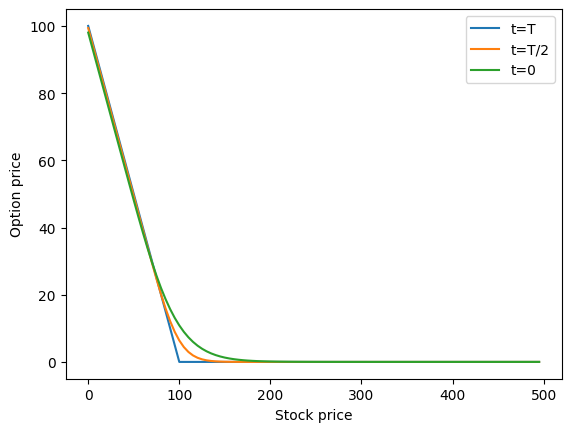

In [133]:

# -----------------------
# Parameters
# Option parameters
r = 0.1 #interest rate
K = 100 # strike
S0 = 100 # Current price 
sigma = 0.6 # volatility
c = 0.02 # dividend yield
T = 1 # Expiry time (years)

# Grid parameters
Smax = 500 # Max stock price
dS = 5 # grid size (stock price grio)
dt = 0.0001 # grid size (time grid)



S_grid = np.arange(0,Smax,dS)
nT = int(T/dt)

Price_grid = FiniteDiff("Put",K,sigma,r,c,Smax,dS,T,dt )

t1, t2, t3 = T, T/2, 3*T/4
n1, n2, n3 = int(t1*nT/T), int(t2*nT/T), int(t3*nT/T)

plt.plot(S_grid,Price_grid[n1], label="t=T")
plt.plot(S_grid,Price_grid[n1-800], label="t=T/2")
plt.plot(S_grid,Price_grid[n3], label="t=0")
#plt.xlim(00,200)
#plt.ylim(-3,20)
plt.xlabel("Stock price")
plt.ylabel("Option price")
plt.legend()
plt.show()

/var/folders/53/85zwmkmn6dv27k0hq0vkmqh80000gn/T/ipykernel_76503/1714338942.py:55: RuntimeWarning: divide by zero encountered in log
  d1 = (np.log(St_arr/K)+(r-c+0.5*sigma**2)*t_period)/(sigma*np.sqrt(t_period))


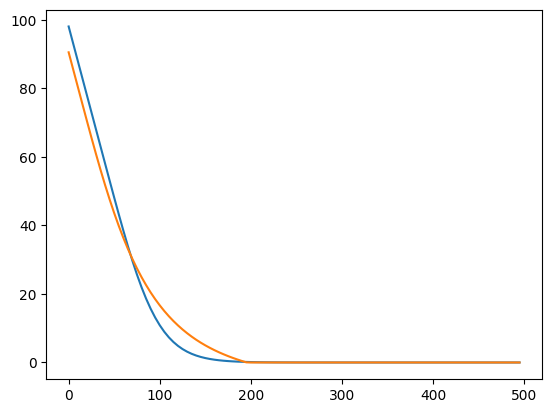

In [134]:
Price_grid_exc = OptionPriceAnalytical("Put",100,sigma,r,c,S_grid,T,0)
plt.plot(S_grid,Price_grid[n3], label="t=0")
plt.plot(S_grid,Price_grid_exc, label="t=T")